In [4]:
# @title Загрузка и распаковка архива
%pip install wget   # если не установлен
import wget

url = 'https://github.com/selfedu-rus/neuro-pytorch/raw/main/dataset_gen_reg.zip'
wget.download(url=url, out='.')
%unzip dataset_gen_reg.zip

# Удаляем скачанный архив (необязательно)
%rm dataset_gen_reg.zip


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: Invalid requirement: '#': Expected package name at the start of dependency specifier
    #
    ^


Note: you may need to restart the kernel to use updated packages.


UsageError: Line magic function `%unzip` not found.


In [7]:
# Для Windows
from pathlib import Path
import requests
from zipfile import ZipFile
from io import BytesIO

url = 'https://github.com/selfedu-rus/neuro-pytorch/raw/main/dataset_gen_reg.zip'
out_dir = Path('./datasets')
out_dir.mkdir(parents=True, exist_ok=True)

resp = requests.get(url)
resp.raise_for_status()
with ZipFile(BytesIO(resp.content)) as zf:
    zf.extractall(out_dir)

print("Архив распакован в", out_dir)

Архив распакован в datasets


In [43]:
import os
import json

from tqdm import tqdm
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
import torchvision.transforms.v2 as tfs

In [35]:
class SunDataset(data.Dataset):
    def __init__(self, path, train=True, transform=None):
        self.path = os.path.join(path, "train" if train else "test")
        self.transform = transform
 
        with open(os.path.join(self.path, "format.json"), "r") as fp:
            self.format = json.load(fp)
 
        self.length = len(self.format)
        self.files = tuple(self.format.keys())
        self.targets = tuple(self.format.values())
 
    def __getitem__(self, item):
        path_file = os.path.join(self.path, self.files[item])
        img = Image.open(path_file).convert('RGB')
 
        if self.transform:
            img = self.transform(img)
 
        return img, torch.tensor(self.targets[item], dtype=torch.float32)
 
    def __len__(self):
        return self.length

In [36]:
transforms = tfs.Compose([tfs.ToImage(), tfs.ToDtype(torch.float32, scale=True)])
d_train = SunDataset("dataset_reg", transform=transforms)
train_data = data.DataLoader(d_train, batch_size=32, shuffle=True)

In [37]:
model = nn.Sequential(
    nn.Conv2d(3, 32, 3, padding='same'),
    nn.ReLU(),
    nn.MaxPool2d(2),
    nn.Conv2d(32, 8, 3, padding='same'),
    nn.ReLU(),
    nn.MaxPool2d(2),
    nn.Conv2d(8, 4, 3, padding='same'),
    nn.ReLU(),
    nn.MaxPool2d(2),
    nn.Flatten(),
    nn.Linear(4096, 128),
    nn.ReLU(),
    nn.Linear(128, 2)
)

In [38]:
optimizer = optim.Adam(params=model.parameters(), lr=0.001, weight_decay=0.001)
loss_function = nn.MSELoss()

In [40]:
epochs = 5
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
model.train()
 
for _e in range(epochs):
    loss_mean = 0
    lm_count = 0
 
    train_tqdm = tqdm(train_data, leave=True)
    for x_train, y_train in train_tqdm:
        x_train = x_train.to(device)
        y_train = y_train.to(device)
        predict = model(x_train)
        loss = loss_function(predict, y_train)
 
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
 
        lm_count += 1
        loss_mean = 1/lm_count * loss.item() + (1 - 1/lm_count) * loss_mean
        train_tqdm.set_description(f"Epoch [{_e+1}/{epochs}], loss_mean={loss_mean:.3f}")

Epoch [5/5], loss_mean=4.686: 100%|██████████| 313/313 [01:37<00:00,  3.21it/s]


In [41]:
st = model.state_dict()
torch.save(st, 'model_sun.tar')

In [ ]:
d_test = SunDataset("dataset_reg", train=False, transform=transforms)
test_data = data.DataLoader(d_test, batch_size=50, shuffle=False)
 
# тестирование обученной НС
Q = 0
count = 0
model.eval()
 
test_tqdm = tqdm(test_data, leave=True)
for x_test, y_test in test_tqdm:
    with torch.no_grad():
        p = model(x_test)
        Q += loss_function(p, y_test).item()
        count += 1
 
Q /= count
print(Q)

100%|██████████| 20/20 [00:04<00:00,  4.36it/s]

3.277096176147461


tensor([[75.9278, 76.5458]], grad_fn=<AddmmBackward0>)
[75, 72]


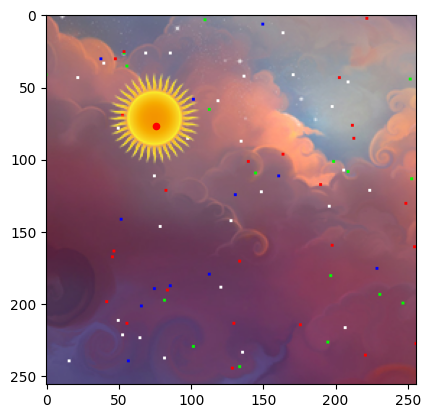

In [47]:
path = 'dataset_reg/test/'
num_img = 123

st = torch.load('model_sun.tar', weights_only=False)
model.load_state_dict(st)

with open(os.path.join(path, "format.json"), "r") as fp:
    format = json.load(fp)

transforms = tfs.Compose([tfs.ToImage(), tfs.ToDtype(torch.float32, scale=True)])
img = Image.open(os.path.join(path, f'sun_reg_{num_img}.png')).convert('RGB')
img_t = transforms(img).unsqueeze(0)

model.eval()
predict = model(img_t)
print(predict)
print(tuple(format.values())[num_img-1])
p = predict.detach().squeeze().numpy()

plt.imshow(img)
plt.scatter(p[0], p[1], s=20, c='r')
plt.show()

# Задания

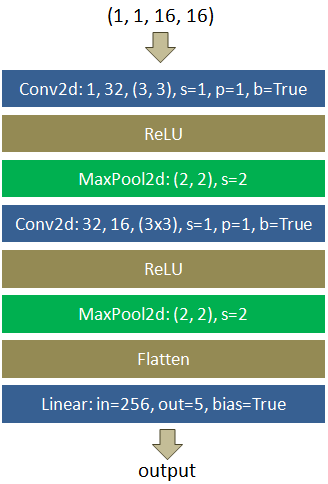

In [ ]:
import torch
import torch.nn as nn

x = torch.rand(1, 16, 16) # тензор x в программе не менять

model = nn.Sequential(
    nn.Conv2d(in_channels=1, out_channels=32, kernel_size=(3, 3), stride=1, padding=1, bias=True),
    nn.ReLU(inplace=True),
    nn.MaxPool2d(kernel_size=(2, 2), stride=2),
    nn.Conv2d(in_channels=32, out_channels=16, kernel_size=(3, 3), stride=1, padding=1, bias=True),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=(2, 2), stride=2),
    nn.Flatten(),
    nn.Linear(in_features=256, out_features=5, bias=True)
)

predict = model(x.unsqueeze(0))
predict

tensor([[-0.0425, -0.0726,  0.1519,  0.0765,  0.0397]],
       grad_fn=<AddmmBackward0>)

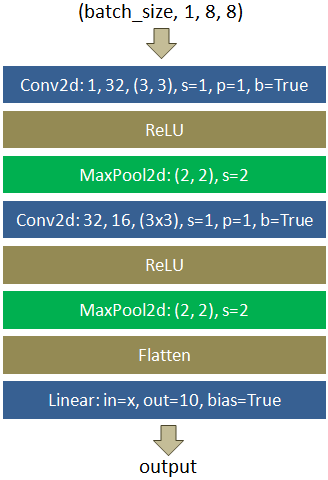

In [55]:
# @title загрузка датасета Digits на диск
from sklearn.datasets import load_digits
import torch


digits = load_digits()

# Признаки и целевые значения
_global_var_data_x = torch.tensor(digits.data, dtype=torch.float32).view(-1, 1, 8, 8)
_global_var_target = torch.tensor(digits.target, dtype=torch.int64)

In [76]:
import torch
import torch.utils.data as data
import torch.nn as nn
import torch.optim as optim

ds = data.TensorDataset(_global_var_data_x, _global_var_target)
dl = data.DataLoader(ds, batch_size=len(ds), shuffle=False)

# здесь продолжайте программу
model = nn.Sequential(
    nn.Conv2d(in_channels=1, out_channels=32, kernel_size=(3, 3), stride=1, padding=1, bias=True),
    nn.ReLU(inplace=True),
    nn.MaxPool2d(kernel_size=(2, 2), stride=2),
    nn.Conv2d(in_channels=32, out_channels=16, kernel_size=(3, 3), stride=1, padding=1, bias=True),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=(2, 2), stride=2),
    nn.Flatten(),
    nn.Linear(in_features=64, out_features=10, bias=True)
)

# 
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.1, momentum=0.9)

for epoch in range(5):
    for batch_x, batch_y in dl:
        optimizer.zero_grad()

        logits = model(batch_x)
        loss = criterion(logits, batch_y)

        loss.backward()
        optimizer.step()

_global_model_state = model.state_dict()
# 

model.load_state_dict(_global_model_state)

model.eval()

x_test, y_test = next(iter(dl))

with torch.no_grad():
    p = model(x_test)
    pm = torch.argmax(p, dim=1)
    Q = torch.sum(pm.flatten() == y_test.flatten()).item()

Q /= len(ds)
Q

0.10962715637173066